REALIZADO POR: TANIA PAMELA APAZA VILCA

Encontrar grupos en el dataset “20 Newsgroups Dataset” de scikit-learn a través de clustering jerárquico. Debe demostrar que se ha probado por lo menos dos criterios diferentes de Linkage y determinar cuál ha tenido más éxito. Además explique los hallazgos que ha realizado el clustering.


In [1]:
# Importar librerías para manipulación de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset y preprocesamiento de texto
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split

# Modelo de clustering jerárquico
from sklearn.cluster import AgglomerativeClustering

# Métricas para evaluar los clusters
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# Descargar los datos de entrenamiento
# Se eliminan encabezados, pies y citas
newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)

# Guardar textos y categorías reales
textos = newsgroups.data
etiquetas_reales = newsgroups.target
nombres_categorias = newsgroups.target_names

print("Total de documentos:", len(textos))
print("Total de categorías:", len(nombres_categorias))
print("Categorías disponibles:")
print(nombres_categorias)

Total de documentos: 11314
Total de categorías: 20
Categorías disponibles:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
# Crear índices para todos los documentos
indices = np.arange(len(textos))

# Seleccionar 1000 documentos conservando
# aproximadamente la proporción de cada categoría
indices_muestra, _ = train_test_split(
    indices,
    train_size=1000,
    stratify=etiquetas_reales,
    random_state=42
)

# Obtener textos y etiquetas de la muestra
textos_muestra = [textos[i] for i in indices_muestra]
y_real = etiquetas_reales[indices_muestra]

print("Documentos seleccionados:", len(textos_muestra))
print("Categorías representadas:", len(np.unique(y_real)))

Documentos seleccionados: 1000
Categorías representadas: 20


In [4]:
# Convertir los textos en vectores TF-IDF
vectorizador = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    max_df=0.90,
    min_df=2,
    sublinear_tf=True
)

X_tfidf = vectorizador.fit_transform(textos_muestra)

print("Dimensiones de la matriz TF-IDF:", X_tfidf.shape)

Dimensiones de la matriz TF-IDF: (1000, 5000)


In [5]:
# Reducir las características de TF-IDF a 100 componentes
svd = TruncatedSVD(
    n_components=100,
    random_state=42
)

X_reducido = svd.fit_transform(X_tfidf)

# Normalizar los vectores para comparar similitud
X_normalizado = normalize(X_reducido)

print("Dimensiones después de SVD:", X_reducido.shape)

print(
    "Varianza explicada por los 100 componentes:",
    round(svd.explained_variance_ratio_.sum(), 4)
)

Dimensiones después de SVD: (1000, 100)
Varianza explicada por los 100 componentes: 0.2457


In [7]:
# MODELO 1: Clustering jerárquico con Ward
modelo_ward = AgglomerativeClustering(
    n_clusters=20,
    linkage="ward",
    metric="euclidean"
)

# Entrenar Ward con todos los documentos
clusters_ward = modelo_ward.fit_predict(X_reducido)


# MODELO 2: Clustering jerárquico con Average
# Identificar documentos cuyos vectores son distintos de cero
normas = np.linalg.norm(X_reducido, axis=1)

# Crear una máscara para conservar vectores válidos
mascara_validos = normas > 1e-10

# Filtrar los documentos válidos
X_average = X_normalizado[mascara_validos]

# Conservar las etiquetas reales correspondientes
y_average = y_real[mascara_validos]

print("Documentos originales:", len(X_normalizado))
print("Documentos válidos para Average:", len(X_average))
print("Vectores cero eliminados:", np.sum(~mascara_validos))

# Entrenar Average con los vectores válidos
modelo_average = AgglomerativeClustering(
    n_clusters=20,
    linkage="average",
    metric="cosine"
)

clusters_average = modelo_average.fit_predict(X_average)

print("\nClustering Ward finalizado")
print("Clustering Average finalizado")

Documentos originales: 1000
Documentos válidos para Average: 971
Vectores cero eliminados: 29

Clustering Ward finalizado
Clustering Average finalizado


In [8]:
# Evaluar Ward
resultado_ward = {
    "Modelo": "Ward",
    "ARI": adjusted_rand_score(y_real, clusters_ward),
    "NMI": normalized_mutual_info_score(y_real, clusters_ward),
    "Silhouette": silhouette_score(
        X_reducido,
        clusters_ward,
        metric="euclidean"
    )
}

# Evaluar Average con las etiquetas filtradas
resultado_average = {
    "Modelo": "Average",
    "ARI": adjusted_rand_score(y_average, clusters_average),
    "NMI": normalized_mutual_info_score(y_average, clusters_average),
    "Silhouette": silhouette_score(
        X_average,
        clusters_average,
        metric="cosine"
    )
}

# Crear tabla comparativa
resultados = pd.DataFrame([
    resultado_ward,
    resultado_average
])

# Ordenar por ARI
resultados = resultados.sort_values(
    by="ARI",
    ascending=False
).reset_index(drop=True)

print("COMPARACIÓN DE LOS MODELOS")
display(resultados.round(4))

COMPARACIÓN DE LOS MODELOS


,Modelo,ARI,NMI,Silhouette
0,Average,0.1192,0.3203,0.0299
1,Ward,0.0641,0.3123,0.0208


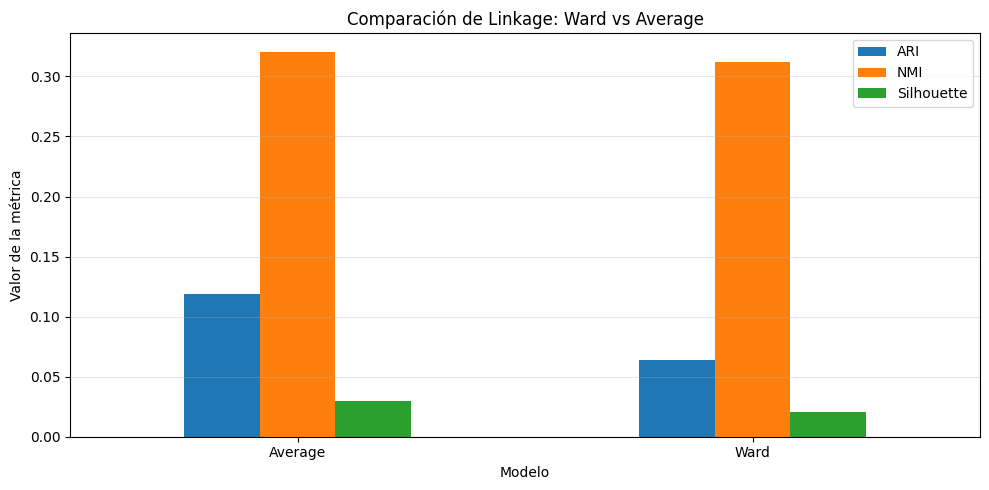

In [9]:
# Graficar las métricas obtenidas por cada modelo
resultados_grafico = resultados.set_index("Modelo")

resultados_grafico[
    ["ARI", "NMI", "Silhouette"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de Linkage: Ward vs Average")
plt.ylabel("Valor de la métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Cantidad de documentos por cluster:


,Ward,Average
Cluster,,
0,36,87
1,299,28
2,29,167
3,62,296
4,106,26
5,21,75
6,53,45
7,18,47
8,36,27


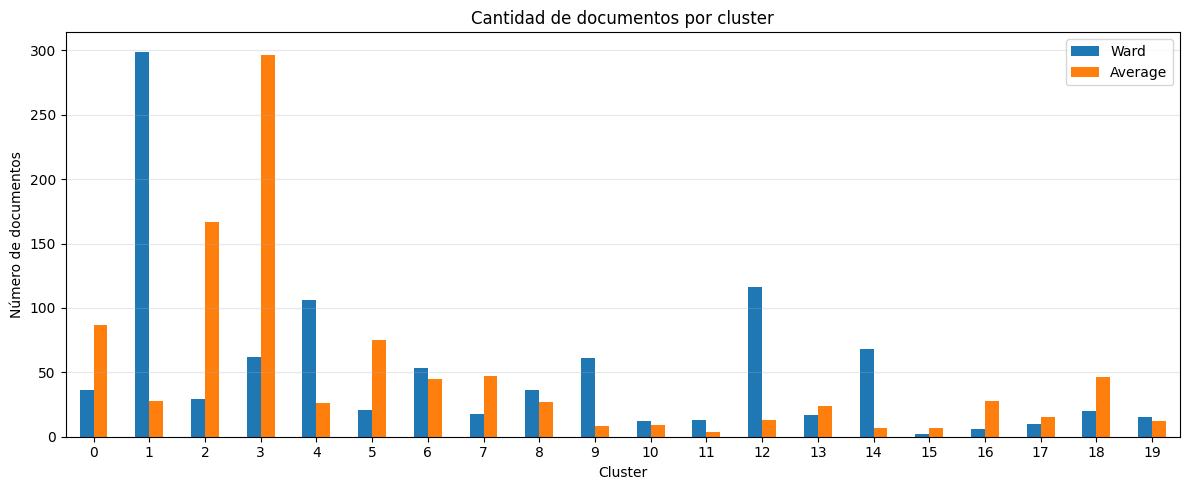

In [10]:
# Contar documentos por cluster
conteo_ward = (
    pd.Series(clusters_ward)
    .value_counts()
    .sort_index()
)

conteo_average = (
    pd.Series(clusters_average)
    .value_counts()
    .sort_index()
)

# Unir los resultados en una tabla
tabla_tamanos = pd.DataFrame({
    "Ward": conteo_ward,
    "Average": conteo_average
}).fillna(0).astype(int)

tabla_tamanos.index.name = "Cluster"

print("Cantidad de documentos por cluster:")
display(tabla_tamanos)

# Graficar distribución de tamaños
tabla_tamanos.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Cantidad de documentos por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de documentos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Obtener los nombres de las palabras del TF-IDF
palabras = vectorizador.get_feature_names_out()


# Función para mostrar las palabras principales
# de cada cluster
def mostrar_palabras_clusters(X, clusters, nombre_modelo):

    print(f"\nPALABRAS REPRESENTATIVAS: {nombre_modelo}")

    for cluster in np.unique(clusters):

        # Obtener índices de los documentos del cluster
        indices_cluster = np.where(clusters == cluster)[0]

        # Seleccionar los documentos del cluster
        documentos_cluster = X[indices_cluster]

        # Calcular el promedio TF-IDF de las palabras
        promedio = np.asarray(
            documentos_cluster.mean(axis=0)
        ).flatten()

        # Obtener las 10 palabras más representativas
        top_indices = promedio.argsort()[-10:][::-1]

        top_palabras = palabras[top_indices]

        print(
            f"\nCluster {cluster} "
            f"({len(indices_cluster)} documentos)"
        )

        print(", ".join(top_palabras))


# Analizar Ward con todos los documentos
mostrar_palabras_clusters(
    X_tfidf,
    clusters_ward,
    "Ward"
)

# Filtrar TF-IDF usando la misma máscara válida de Average
X_tfidf_average = X_tfidf[mascara_validos]

# Analizar Average solo con documentos válidos
mostrar_palabras_clusters(
    X_tfidf_average,
    clusters_average,
    "Average"
)


PALABRAS REPRESENTATIVAS: Ward

Cluster 0 (36 documentos)
card, graphics, monitor, vga, cards, drivers, know, vesa, windows, nec

Cluster 1 (299 documentos)
just, don, time, like, really, think, know, com, try, way

Cluster 2 (29 documentos)
year, huh, deal, baseball, better, hit, like, time, remember, defense

Cluster 3 (62 documentos)
edu, mac, 800, information, version, interested, expensive, using, email, directory

Cluster 4 (106 documentos)
like, car, bit, power, black, just, use, sell, screen, know

Cluster 5 (21 documentos)
printer, adobe, port, print, serial, fonts, does, mouse, ps, adb

Cluster 6 (53 documentos)
thanks, windows, hi, files, advance, program, appreciated, file, pc, greatly

Cluster 7 (18 documentos)
shipping, 00, condition, asking, 50, price, new, 30, manual, offer

Cluster 8 (36 documentos)
team, players, hockey, nhl, cup, season, 10, game, play, winnipeg

Cluster 9 (61 documentos)
god, jesus, christians, christian, bible, believe, faith, people, christ, don


In [12]:
# Función para cruzar clusters con categorías reales
def analizar_categorias(
    clusters,
    etiquetas,
    nombre_modelo
):

    # Convertir etiquetas numéricas a nombres
    categorias = [
        nombres_categorias[i] for i in etiquetas
    ]

    # Crear tabla cruzada
    tabla = pd.crosstab(
        pd.Series(clusters, name="Cluster"),
        pd.Series(categorias, name="Categoría real")
    )

    print(f"\nDistribución de categorías: {nombre_modelo}")
    display(tabla)

    # Identificar categoría predominante por cluster
    resumen = pd.DataFrame({
        "Documentos": tabla.sum(axis=1),
        "Categoría predominante": tabla.idxmax(axis=1),
        "Cantidad predominante": tabla.max(axis=1)
    })

    # Calcular porcentaje de la categoría predominante
    resumen["Porcentaje predominante (%)"] = (
        resumen["Cantidad predominante"]
        / resumen["Documentos"] * 100
    ).round(2)

    print("Resumen de categorías predominantes:")
    display(resumen)


# Analizar Ward con todas las etiquetas reales
analizar_categorias(
    clusters_ward,
    y_real,
    "Ward"
)

# Analizar Average con las etiquetas filtradas
analizar_categorias(
    clusters_average,
    y_average,
    "Average"
)


Distribución de categorías: Ward


Categoría real,alt.atheism,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,misc.forsale,rec.autos,rec.motorcycles,rec.sport.baseball,rec.sport.hockey,sci.crypt,sci.electronics,sci.med,sci.space,soc.religion.christian,talk.politics.guns,talk.politics.mideast,talk.politics.misc,talk.religion.misc
Cluster,,,,,,,,,,,,,,,,,,,,
0,0,12,6,7,10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,16,11,12,10,5,16,7,14,25,24,21,18,20,16,22,13,16,11,14,8
2,0,0,0,0,0,0,0,4,2,17,1,0,0,1,0,1,1,2,0,0
3,1,11,5,4,11,11,5,1,0,0,0,1,4,3,2,0,1,2,0,0
4,2,7,3,9,8,2,15,22,6,1,0,2,17,4,1,1,1,1,1,3
5,0,0,7,4,6,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0
6,0,8,14,7,5,10,0,1,0,0,0,1,1,1,1,2,0,1,1,0
7,0,0,0,0,0,0,17,0,0,0,0,0,1,0,0,0,0,0,0,0
8,0,0,1,1,0,0,0,0,0,7,26,0,0,0,0,0,0,0,0,1


Resumen de categorías predominantes:


,Documentos,Categoría predominante,Cantidad predominante,Porcentaje predominante (%)
Cluster,,,,
0,36,comp.graphics,12,33.33
1,299,rec.motorcycles,25,8.36
2,29,rec.sport.baseball,17,58.62
3,62,comp.graphics,11,17.74
4,106,rec.autos,22,20.75
5,21,comp.os.ms-windows.misc,7,33.33
6,53,comp.os.ms-windows.misc,14,26.42
7,18,misc.forsale,17,94.44
8,36,rec.sport.hockey,26,72.22



Distribución de categorías: Average


Categoría real,alt.atheism,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,misc.forsale,rec.autos,rec.motorcycles,rec.sport.baseball,rec.sport.hockey,sci.crypt,sci.electronics,sci.med,sci.space,soc.religion.christian,talk.politics.guns,talk.politics.mideast,talk.politics.misc,talk.religion.misc
Cluster,,,,,,,,,,,,,,,,,,,,
0,0,1,1,3,0,0,2,21,18,1,1,1,13,0,21,0,2,1,0,1
1,0,3,3,2,3,2,2,4,1,0,0,2,2,2,1,0,1,0,0,0
2,0,29,24,32,30,33,6,1,2,1,0,5,1,2,0,0,0,0,1,0
3,33,3,6,4,1,3,1,7,16,8,5,10,11,28,10,41,35,32,22,20
4,0,0,4,0,1,1,0,1,0,1,1,2,1,2,4,0,1,2,1,4
5,0,0,1,0,0,0,1,0,4,29,39,0,0,0,0,0,0,0,1,0
6,0,0,1,1,1,0,31,1,0,1,0,0,3,1,0,3,1,0,0,1
7,3,2,0,3,0,2,0,1,0,1,0,22,2,1,1,0,1,0,8,0
8,5,4,1,0,0,2,0,3,2,0,0,1,0,1,2,2,0,2,0,2


Resumen de categorías predominantes:


,Documentos,Categoría predominante,Cantidad predominante,Porcentaje predominante (%)
Cluster,,,,
0,87,rec.autos,21,24.14
1,28,rec.autos,4,14.29
2,167,comp.windows.x,33,19.76
3,296,soc.religion.christian,41,13.85
4,26,comp.os.ms-windows.misc,4,15.38
5,75,rec.sport.hockey,39,52.00
6,45,misc.forsale,31,68.89
7,47,sci.crypt,22,46.81
8,27,alt.atheism,5,18.52


In [13]:
# Función para cruzar clusters con categorías reales
def analizar_categorias(
    clusters,
    etiquetas,
    nombre_modelo
):

    # Convertir etiquetas numéricas a nombres
    categorias = [
        nombres_categorias[i] for i in etiquetas
    ]

    # Crear tabla cruzada
    tabla = pd.crosstab(
        pd.Series(clusters, name="Cluster"),
        pd.Series(categorias, name="Categoría real")
    )

    print(f"\nDistribución de categorías: {nombre_modelo}")
    display(tabla)

    # Identificar categoría predominante por cluster
    resumen = pd.DataFrame({
        "Documentos": tabla.sum(axis=1),
        "Categoría predominante": tabla.idxmax(axis=1),
        "Cantidad predominante": tabla.max(axis=1)
    })

    # Calcular porcentaje de la categoría predominante
    resumen["Porcentaje predominante (%)"] = (
        resumen["Cantidad predominante"]
        / resumen["Documentos"] * 100
    ).round(2)

    print("Resumen de categorías predominantes:")
    display(resumen)


# Analizar Ward con todas las etiquetas reales
analizar_categorias(
    clusters_ward,
    y_real,
    "Ward"
)

# Analizar Average con las etiquetas filtradas
analizar_categorias(
    clusters_average,
    y_average,
    "Average"
)


Distribución de categorías: Ward


Categoría real,alt.atheism,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,misc.forsale,rec.autos,rec.motorcycles,rec.sport.baseball,rec.sport.hockey,sci.crypt,sci.electronics,sci.med,sci.space,soc.religion.christian,talk.politics.guns,talk.politics.mideast,talk.politics.misc,talk.religion.misc
Cluster,,,,,,,,,,,,,,,,,,,,
0,0,12,6,7,10,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,16,11,12,10,5,16,7,14,25,24,21,18,20,16,22,13,16,11,14,8
2,0,0,0,0,0,0,0,4,2,17,1,0,0,1,0,1,1,2,0,0
3,1,11,5,4,11,11,5,1,0,0,0,1,4,3,2,0,1,2,0,0
4,2,7,3,9,8,2,15,22,6,1,0,2,17,4,1,1,1,1,1,3
5,0,0,7,4,6,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0
6,0,8,14,7,5,10,0,1,0,0,0,1,1,1,1,2,0,1,1,0
7,0,0,0,0,0,0,17,0,0,0,0,0,1,0,0,0,0,0,0,0
8,0,0,1,1,0,0,0,0,0,7,26,0,0,0,0,0,0,0,0,1


Resumen de categorías predominantes:


,Documentos,Categoría predominante,Cantidad predominante,Porcentaje predominante (%)
Cluster,,,,
0,36,comp.graphics,12,33.33
1,299,rec.motorcycles,25,8.36
2,29,rec.sport.baseball,17,58.62
3,62,comp.graphics,11,17.74
4,106,rec.autos,22,20.75
5,21,comp.os.ms-windows.misc,7,33.33
6,53,comp.os.ms-windows.misc,14,26.42
7,18,misc.forsale,17,94.44
8,36,rec.sport.hockey,26,72.22



Distribución de categorías: Average


Categoría real,alt.atheism,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,misc.forsale,rec.autos,rec.motorcycles,rec.sport.baseball,rec.sport.hockey,sci.crypt,sci.electronics,sci.med,sci.space,soc.religion.christian,talk.politics.guns,talk.politics.mideast,talk.politics.misc,talk.religion.misc
Cluster,,,,,,,,,,,,,,,,,,,,
0,0,1,1,3,0,0,2,21,18,1,1,1,13,0,21,0,2,1,0,1
1,0,3,3,2,3,2,2,4,1,0,0,2,2,2,1,0,1,0,0,0
2,0,29,24,32,30,33,6,1,2,1,0,5,1,2,0,0,0,0,1,0
3,33,3,6,4,1,3,1,7,16,8,5,10,11,28,10,41,35,32,22,20
4,0,0,4,0,1,1,0,1,0,1,1,2,1,2,4,0,1,2,1,4
5,0,0,1,0,0,0,1,0,4,29,39,0,0,0,0,0,0,0,1,0
6,0,0,1,1,1,0,31,1,0,1,0,0,3,1,0,3,1,0,0,1
7,3,2,0,3,0,2,0,1,0,1,0,22,2,1,1,0,1,0,8,0
8,5,4,1,0,0,2,0,3,2,0,0,1,0,1,2,2,0,2,0,2


Resumen de categorías predominantes:


,Documentos,Categoría predominante,Cantidad predominante,Porcentaje predominante (%)
Cluster,,,,
0,87,rec.autos,21,24.14
1,28,rec.autos,4,14.29
2,167,comp.windows.x,33,19.76
3,296,soc.religion.christian,41,13.85
4,26,comp.os.ms-windows.misc,4,15.38
5,75,rec.sport.hockey,39,52.00
6,45,misc.forsale,31,68.89
7,47,sci.crypt,22,46.81
8,27,alt.atheism,5,18.52


In [14]:
# Obtener el modelo con mayor ARI
mejor_fila = resultados.loc[
    resultados["ARI"].idxmax()
]

mejor_modelo = mejor_fila["Modelo"]

print("===== MODELO CON MAYOR ÉXITO SEGÚN ARI =====")
print("Modelo:", mejor_modelo)
print("ARI:", round(mejor_fila["ARI"], 4))
print("NMI:", round(mejor_fila["NMI"], 4))
print("Silhouette:", round(mejor_fila["Silhouette"], 4))


# Comparar los resultados de ambos modelos
print("\n===== TABLA COMPARATIVA FINAL =====")
display(resultados.round(4))


# Generar una conclusión automática
print("\n===== CONCLUSIÓN =====")

if mejor_modelo == "Ward":
    print(
        "Ward obtuvo el mayor ARI, por lo que presentó "
        "una mayor correspondencia con las categorías "
        "originales del dataset en esta ejecución."
    )
else:
    print(
        "Average obtuvo el mayor ARI, por lo que presentó "
        "una mayor correspondencia con las categorías "
        "originales del dataset en esta ejecución."
    )

print(
    "La interpretación temática de los clusters debe "
    "complementarse con las palabras representativas "
    "y la distribución de categorías."
)

===== MODELO CON MAYOR ÉXITO SEGÚN ARI =====
Modelo: Average
ARI: 0.1192
NMI: 0.3203
Silhouette: 0.0299

===== TABLA COMPARATIVA FINAL =====


,Modelo,ARI,NMI,Silhouette
0,Average,0.1192,0.3203,0.0299
1,Ward,0.0641,0.3123,0.0208



===== CONCLUSIÓN =====
Average obtuvo el mayor ARI, por lo que presentó una mayor correspondencia con las categorías originales del dataset en esta ejecución.
La interpretación temática de los clusters debe complementarse con las palabras representativas y la distribución de categorías.


b Ejemplificar la segmentación de clientes usando clustering jerárquico. Use diferentes Linkages y explique sus hallazgos. [Hint: Podría usar el dataset: Mall Customer Dataset de Kaggle, uno sintético como make_blobs de scikit learn, u otro]

In [15]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Crear datos sintéticos de clientes
X, etiquetas_reales = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.2,
    random_state=42
)

# Crear DataFrame
clientes = pd.DataFrame(
    X,
    columns=["Frecuencia_Compra", "Monto_Gasto"]
)

print("Cantidad de clientes:", len(clientes))
clientes.head()

Cantidad de clientes: 300


,Frecuencia_Compra,Monto_Gasto
0,-9.389561,6.303710
1,-9.870824,6.862056
2,-1.522144,7.549274
3,-7.140845,-5.561577
4,-11.284077,6.113819


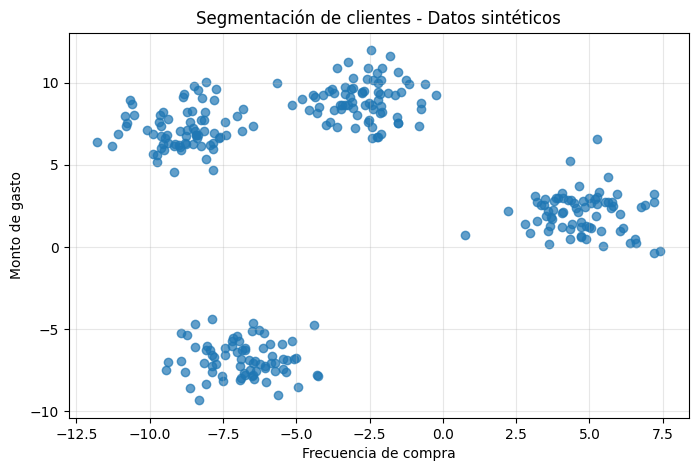

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    clientes["Frecuencia_Compra"],
    clientes["Monto_Gasto"],
    alpha=0.7
)

plt.title("Segmentación de clientes - Datos sintéticos")
plt.xlabel("Frecuencia de compra")
plt.ylabel("Monto de gasto")
plt.grid(alpha=0.3)

plt.show()

In [17]:
# Crear modelos con diferentes criterios de Linkage

modelo_ward = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward",
    metric="euclidean"
)

modelo_complete = AgglomerativeClustering(
    n_clusters=4,
    linkage="complete",
    metric="euclidean"
)

modelo_average = AgglomerativeClustering(
    n_clusters=4,
    linkage="average",
    metric="euclidean"
)

# Obtener los clusters
cluster_ward = modelo_ward.fit_predict(X)

cluster_complete = modelo_complete.fit_predict(X)

cluster_average = modelo_average.fit_predict(X)

print("Los tres modelos fueron ejecutados correctamente.")

Los tres modelos fueron ejecutados correctamente.


In [18]:
# Calcular Silhouette para cada Linkage

silhouette_ward = silhouette_score(
    X, cluster_ward
)

silhouette_complete = silhouette_score(
    X, cluster_complete
)

silhouette_average = silhouette_score(
    X, cluster_average
)

# Crear tabla comparativa
resultados_clientes = pd.DataFrame({
    "Linkage": [
        "Ward",
        "Complete",
        "Average"
    ],
    "Silhouette": [
        silhouette_ward,
        silhouette_complete,
        silhouette_average
    ]
})

resultados_clientes = resultados_clientes.sort_values(
    by="Silhouette",
    ascending=False
).reset_index(drop=True)

display(resultados_clientes.round(4))

,Linkage,Silhouette
0,Ward,0.7518
1,Complete,0.7518
2,Average,0.7494


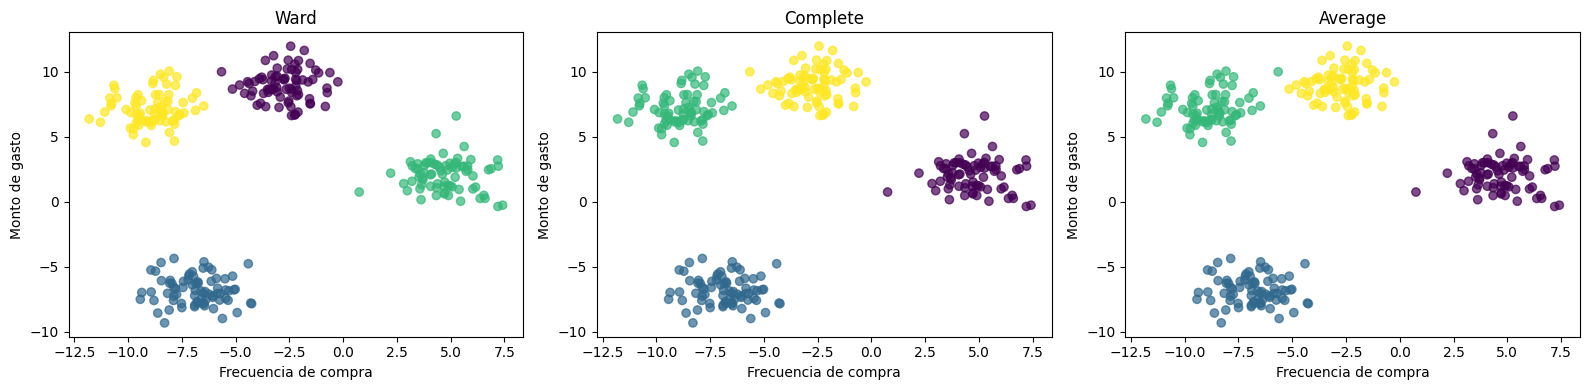

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Ward
axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=cluster_ward,
    alpha=0.7
)
axes[0].set_title("Ward")
axes[0].set_xlabel("Frecuencia de compra")
axes[0].set_ylabel("Monto de gasto")

# Complete
axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=cluster_complete,
    alpha=0.7
)
axes[1].set_title("Complete")
axes[1].set_xlabel("Frecuencia de compra")
axes[1].set_ylabel("Monto de gasto")

# Average
axes[2].scatter(
    X[:, 0],
    X[:, 1],
    c=cluster_average,
    alpha=0.7
)
axes[2].set_title("Average")
axes[2].set_xlabel("Frecuencia de compra")
axes[2].set_ylabel("Monto de gasto")

plt.tight_layout()
plt.show()

In [20]:
# Obtener el mejor Linkage según Silhouette
mejor = resultados_clientes.iloc[0]

print("===== MEJOR LINKAGE =====")
print("Linkage:", mejor["Linkage"])
print("Silhouette:", round(mejor["Silhouette"], 4))

===== MEJOR LINKAGE =====
Linkage: Ward
Silhouette: 0.7518


Use clustering jerárquico para segmentar imágenes. Explique sus hallazgos [Hint: Podría usar el dataset BSDS500 u otro].


In [21]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_sample_image

Dimensiones originales: (427, 640, 3)


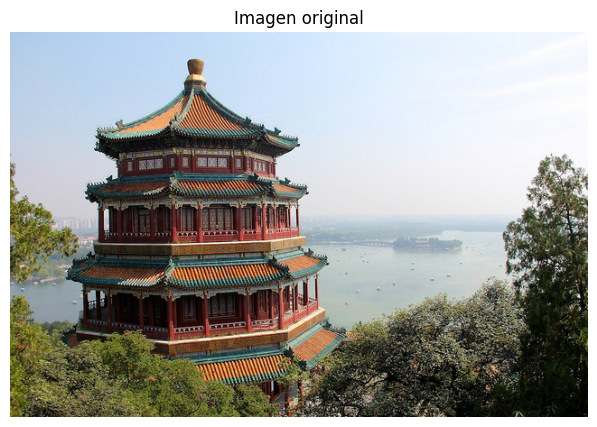

In [31]:
# Cargar una imagen de ejemplo incluida en scikit-learn
imagen = load_sample_image("china.jpg")

print("Dimensiones originales:", imagen.shape)

# Mostrar imagen original
plt.figure(figsize=(8, 5))
plt.imshow(imagen)
plt.title("Imagen original")
plt.axis("off")
plt.show()

In [32]:
from skimage.transform import resize

# Reducir la imagen para que el clustering sea más rápido
imagen_pequena = resize(
    imagen,
    (60, 60),
    anti_aliasing=True
)

# Convertir cada píxel en una fila
# Cada fila tendrá: R, G y B
pixeles = imagen_pequena.reshape(-1, 3)

print("Tamaño de la imagen:", imagen_pequena.shape)
print("Cantidad de píxeles:", pixeles.shape[0])
print("Características por píxel:", pixeles.shape[1])

Tamaño de la imagen: (60, 60, 3)
Cantidad de píxeles: 3600
Características por píxel: 3


In [33]:
# Número de segmentos que queremos obtener
n_clusters = 5

# Clustering jerárquico con Ward
modelo_ward = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

labels_ward = modelo_ward.fit_predict(pixeles)

# Clustering jerárquico con Complete
modelo_complete = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="complete"
)

labels_complete = modelo_complete.fit_predict(pixeles)

print("Segmentos obtenidos con Ward:", len(np.unique(labels_ward)))
print("Segmentos obtenidos con Complete:", len(np.unique(labels_complete)))

Segmentos obtenidos con Ward: 5
Segmentos obtenidos con Complete: 5


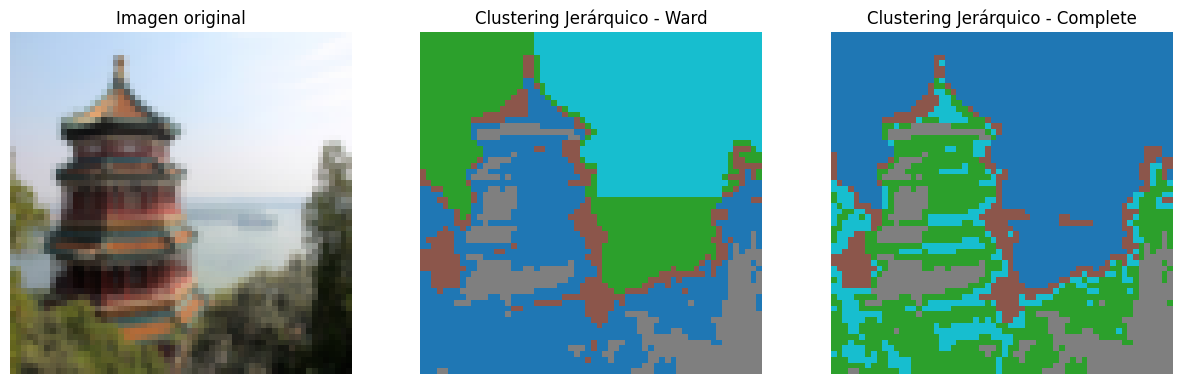

In [34]:
# Convertir las etiquetas de cada píxel nuevamente a forma de imagen
segmentada_ward = labels_ward.reshape(60, 60)
segmentada_complete = labels_complete.reshape(60, 60)

# Mostrar resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen_pequena)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmentada_ward, cmap="tab10")
plt.title("Clustering Jerárquico - Ward")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(segmentada_complete, cmap="tab10")
plt.title("Clustering Jerárquico - Complete")
plt.axis("off")

plt.show()

In [35]:
from sklearn.metrics import silhouette_score

silhouette_ward = silhouette_score(pixeles, labels_ward)
silhouette_complete = silhouette_score(pixeles, labels_complete)

print(f"Silhouette - Ward: {silhouette_ward:.4f}")
print(f"Silhouette - Complete: {silhouette_complete:.4f}")

Silhouette - Ward: 0.4913
Silhouette - Complete: 0.5040


In [36]:
resultados = []

for k in range(3, 9):
    modelo = AgglomerativeClustering(
        n_clusters=k,
        linkage="complete"
    )

    labels = modelo.fit_predict(pixeles)
    sil = silhouette_score(pixeles, labels)

    resultados.append((k, sil))

print("Resultados:")
for k, sil in resultados:
    print(f"Segmentos: {k} | Silhouette: {sil:.4f}")

Resultados:
Segmentos: 3 | Silhouette: 0.5747
Segmentos: 4 | Silhouette: 0.5386
Segmentos: 5 | Silhouette: 0.5040
Segmentos: 6 | Silhouette: 0.4607
Segmentos: 7 | Silhouette: 0.4550
Segmentos: 8 | Silhouette: 0.4322


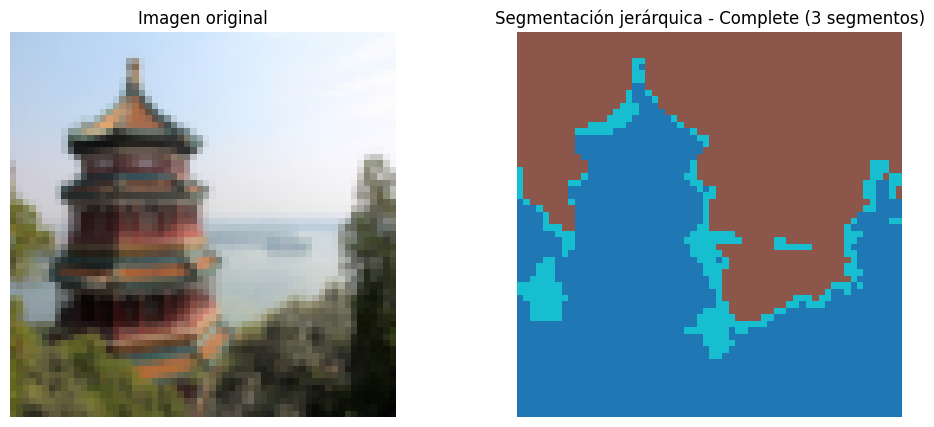

In [37]:
modelo_final = AgglomerativeClustering(
    n_clusters=3,
    linkage="complete"
)

labels_final = modelo_final.fit_predict(pixeles)

segmentada_final = labels_final.reshape(60, 60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imagen_pequena)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmentada_final, cmap="tab10")
plt.title("Segmentación jerárquica - Complete (3 segmentos)")
plt.axis("off")

plt.show()